# Audio processing introduction

This tutorial aims to introduce the basics of digital audio processing.

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

## 1. Load audio file

In [2]:
path = "./example.wav"

Use librosa.load to load the example audio file. Print the sampling rate. How do you open the file with its native sampling rate?

In [3]:
wav, sr = librosa.load(path, sr=None)

In [4]:
sr

16000

Plot the audio file.

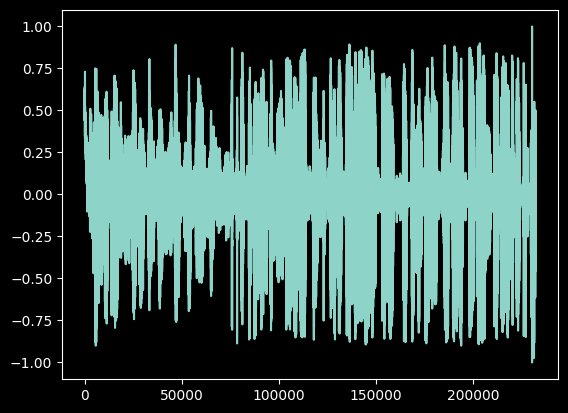

In [5]:
plt.plot(wav)

## 2. Spectrogram

Next, we want to display the audio as a spectrogram.

Use the matplotlib specgram function to plot the spectrogram of the waveform.

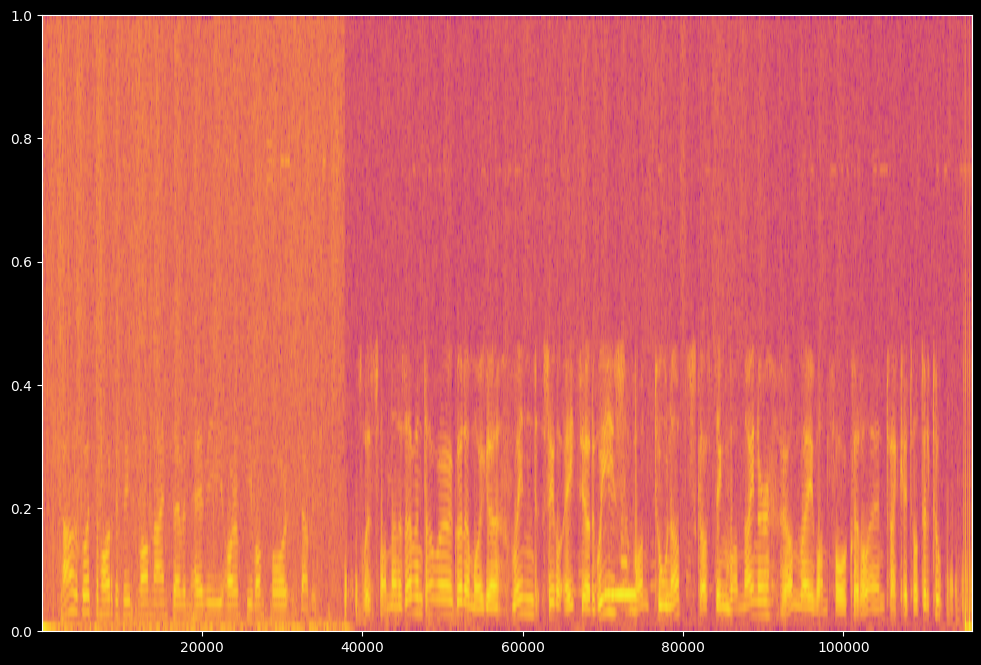

In [6]:
plt.figure(figsize=(12, 8))
plt.specgram(wav, cmap='plasma')
plt.show()

Observe the difference in background noise for different speakers. Also observe how the speech is reflected in the spectrogram.

## 3. MFCC

Finally, we want to represent audio using MFCCs.

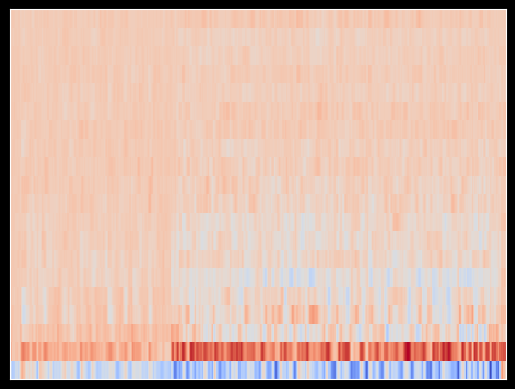

In [7]:
librosa.display.specshow(librosa.feature.mfcc(y=wav, sr=sr))

Let's try to break down the MFCC calculation!

First, apply short term fourier transform, with a window size of 25 ms, stride of 10 ms. (Hint: take the absolute magnitude of the fourier transform)

In [8]:
window_size = int(0.025 * sr)  # 25ms in samples
stride = int(0.010 * sr)       # 10ms in samples

In [9]:
fft = np.abs(librosa.stft(wav, n_fft=window_size, hop_length=stride))

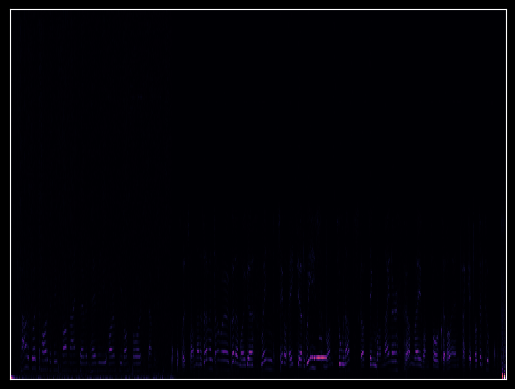

In [10]:
librosa.display.specshow(fft)

Create a mel filter with 20 bins

In [11]:
mel_filter = librosa.filters.mel(sr=sr, n_fft=window_size, n_mels=20)

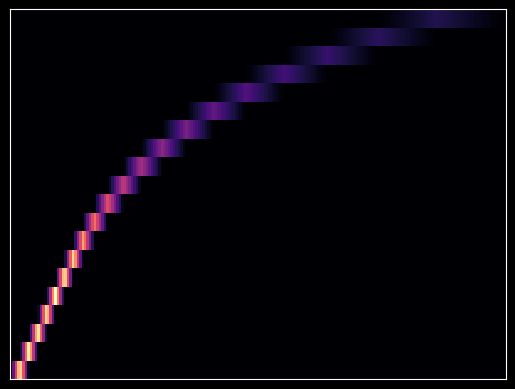

In [12]:
librosa.display.specshow(mel_filter)

_Bonus question: what is the minimum and maximum frequency of the mel bins?_

_By default, librosa spans from 0 Hz to sr/2 (Nyquist frequency), but distributed on the mel scale so bins are denser at low frequencies._

Calculate the log-mel spectrogram. (Hint: what are the shapes of the mel filter and log fft? What operation can we use to combine them?)

In [13]:
mel_spec = mel_filter @ fft  # (20, n_fft/2+1) @ (n_fft/2+1, T) -> (20, T)

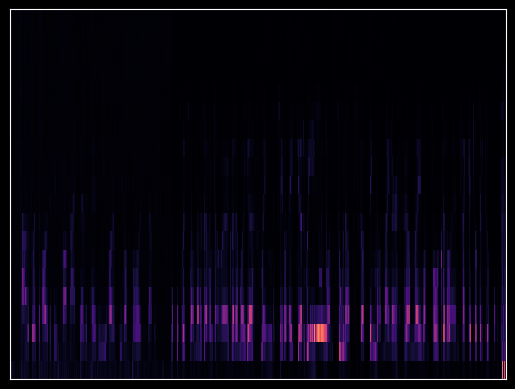

In [14]:
librosa.display.specshow(mel_spec)

Next, calculate the logarithm of the resulting transform.

In [15]:
log_mel = np.log(mel_spec + 1e-9)  # epsilon avoids log(0)

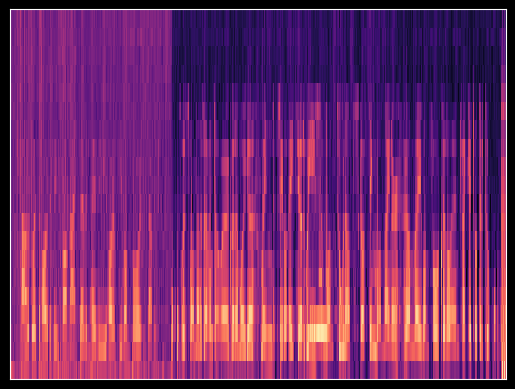

In [16]:
librosa.display.specshow(log_mel)

Finally, calculate the cepstral coefficients by applying a discrete cosine transform. Keep only the first 20 channels.

In [17]:
import scipy.fftpack

mfcc = scipy.fftpack.dct(log_mel, axis=0, norm='ortho')[:20]

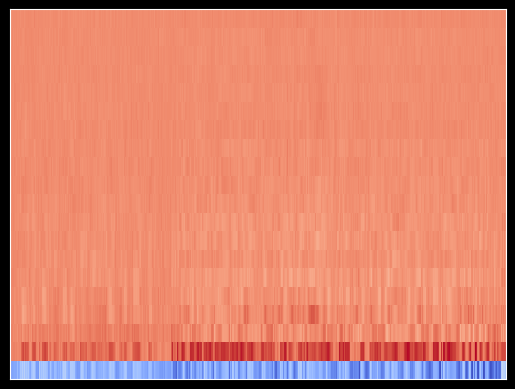

In [18]:
librosa.display.specshow(mfcc)

Congratulations! You have calculated an MFCC from scratch.